<a href="https://colab.research.google.com/github/nileshgarg-tech/mortgage-ai-document-intelligence/blob/main/Basic_Resume_Parser_with_PyMuPDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resume Parser with PyMuPDF

## Step 1: Setup Environment

In [1]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 24.9 MB/s eta 0:00:00


Upload resume File

In [9]:
from google.colab import files
uploaded = files.upload()

Saving Nilesh-Garg-Honors Computer Science Student.pdf to Nilesh-Garg-Honors Computer Science Student.pdf


In [3]:
import os
print(os.listdir())


['.config', 'Nilesh G.pdf', 'sample_data']


## Step 2: Inspecting the PDF

In [6]:
import fitz

In [10]:
# Load the PDF
doc = fitz.open("Nilesh-Garg-Honors Computer Science Student.pdf")


# Print the number of pages
print(f"Total Pages: {doc.page_count}")


# Print metadata
print("PDF Metadata:")

doc.metadata


Total Pages: 2
PDF Metadata:


{'format': 'PDF 1.4',
 'title': 'Resume Viewer',
 'author': '',
 'subject': '',
 'keywords': '',
 'creator': 'Chromium',
 'producer': 'Skia/PDF m132',
 'creationDate': "D:20250701185853+00'00'",
 'modDate': "D:20250701185853+00'00'",
 'trapped': '',
 'encryption': None}

## Step 3: Extracting Text from a PDF

### Extracting Raw Text from a Page

In [11]:
# Open the first page of the document
page = doc[0]

# Extract text as a plain string
text = page.get_text("text")

# Print the extracted text
print(text)

HOUSTON, US, 77204 • NGARG@COUGARNET.UH.EDU • (832) 792-5633
NILESH GARG
Honors Computer Science Student
PROFESSIONAL SUMMARY
AI Explorer & Computer Science Student passionate about leveraging artificial intelligence to revolutionize industries.
Experienced in developing end-to-end AI prototypes, organizing hackathons, and building scalable ML solutions. Strong
background in deep learning frameworks, cloud platforms, and agent-based systems with proven ability to deliver results under
tight deadlines.
EMPLOYMENT HISTORY
CO-ORGANIZER, VIBE CODING HACKATHON
May 2025 - Jun 2025
C.T. Bauer College of Business, University of Houston
RESEARCH GUIDE AUTHOR
Oct 2024 - May 2025
University of Houston Library
• Authored comprehensive methodology guides for Computer Science and Earth & Atmospheric Sciences
• Simplified complex technical processes for student and faculty reference
AI TECH EVANGELIST & CONTENT CREATOR
Present
Self-Directed Professional Development
• Engaged with venture capitalists 

### Extracting Text with Bounding Box Positions

In [12]:
# Extract words along with bounding box information
words = page.get_text("words")

# Print first 5 extracted words with bounding boxes
for word in words[:5]:
    print(word)

(123.99609375, 41.307228088378906, 178.7113800048828, 51.807228088378906, 'HOUSTON,', 0, 0, 0)
(180.81137084960938, 41.307228088378906, 195.85781860351562, 51.807228088378906, 'US,', 0, 0, 1)
(197.95779418945312, 41.307228088378906, 223.15769958496094, 51.807228088378906, '77204', 0, 0, 2)
(229.16015625, 41.307228088378906, 232.8141632080078, 51.807228088378906, '•', 0, 0, 3)
(238.81640625, 40.134246826171875, 393.8377685546875, 51.807228088378906, 'NGARG@COUGARNET.UH.EDU', 0, 0, 4)


### Extracting Text Block-by-Block (Paragraph-Level)

In [13]:
# Extract structured text as blocks
blocks = page.get_text("blocks")

# Print each block
for block in blocks:
    print(f"Block: {block}")

Block: (123.99609375, 40.134246826171875, 471.49176025390625, 51.807228088378906, 'HOUSTON, US, 77204 • NGARG@COUGARNET.UH.EDU • (832) 792-5633\n', 0, 0)
Block: (212.859375, 54.71794891357422, 381.8916015625, 78.71794891357422, 'NILESH GARG\n', 1, 0)
Block: (231.90234375, 85.5302734375, 363.5508728027344, 96.0302734375, 'Honors Computer Science Student\n', 2, 0)
Block: (218.70703125, 106.8499984741211, 376.5479736328125, 118.8499984741211, 'PROFESSIONAL SUMMARY\n', 3, 0)
Block: (42.0, 134.63424682617188, 545.0950927734375, 186.80723571777344, 'AI Explorer & Computer Science Student passionate about leveraging artificial intelligence to revolutionize industries.\nExperienced in developing end-to-end AI prototypes, organizing hackathons, and building scalable ML solutions. Strong\nbackground in deep learning frameworks, cloud platforms, and agent-based systems with proven ability to deliver results under\ntight deadlines.\n', 4, 0)
Block: (225.22265625, 198.35000610351562, 370.03515625, 

## Step 4: Extracting Text from All Pages in a PDF

In [14]:
# Loop through all pages and extract text
for page_num in range(len(doc)):
    page = doc[page_num]
    text = page.get_text("text")
    print(f"--- Page {page_num + 1} ---")
    print(text)

--- Page 1 ---
HOUSTON, US, 77204 • NGARG@COUGARNET.UH.EDU • (832) 792-5633
NILESH GARG
Honors Computer Science Student
PROFESSIONAL SUMMARY
AI Explorer & Computer Science Student passionate about leveraging artificial intelligence to revolutionize industries.
Experienced in developing end-to-end AI prototypes, organizing hackathons, and building scalable ML solutions. Strong
background in deep learning frameworks, cloud platforms, and agent-based systems with proven ability to deliver results under
tight deadlines.
EMPLOYMENT HISTORY
CO-ORGANIZER, VIBE CODING HACKATHON
May 2025 - Jun 2025
C.T. Bauer College of Business, University of Houston
RESEARCH GUIDE AUTHOR
Oct 2024 - May 2025
University of Houston Library
• Authored comprehensive methodology guides for Computer Science and Earth & Atmospheric Sciences
• Simplified complex technical processes for student and faculty reference
AI TECH EVANGELIST & CONTENT CREATOR
Present
Self-Directed Professional Development
• Engaged with ventu

## Step 5: Extracting Key Information from a PDF

In [15]:
import re

# Extract raw text from the first page
text = doc[0].get_text("text")

# Use regex to find a phone number in the text
phone_match = re.search(r"\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}", text)

if phone_match:
    phone_number = phone_match.group()
    print(f"Candidate Phone Number: {phone_number}")
else:
    print("Phone number not found.")

Candidate Phone Number: (832) 792-5633


## Step 6: Extracting Bounding Boxes for Specific Fields

In [16]:
# Extract words with their bounding boxes
words = doc[0].get_text("words")

# Define the field we are looking for
target_word = phone_number

# Search for the target word and retrieve its bounding box
for word in words:
    x0, y0, x1, y1, text, block, line, word_no = word  # Unpack correctly
    if target_word.lower() in text.lower():  # Case-insensitive match
        print(f"Found '{target_word}' at: ({x0}, {y0}, {x1}, {y1})")

'8327925633' not found in document.


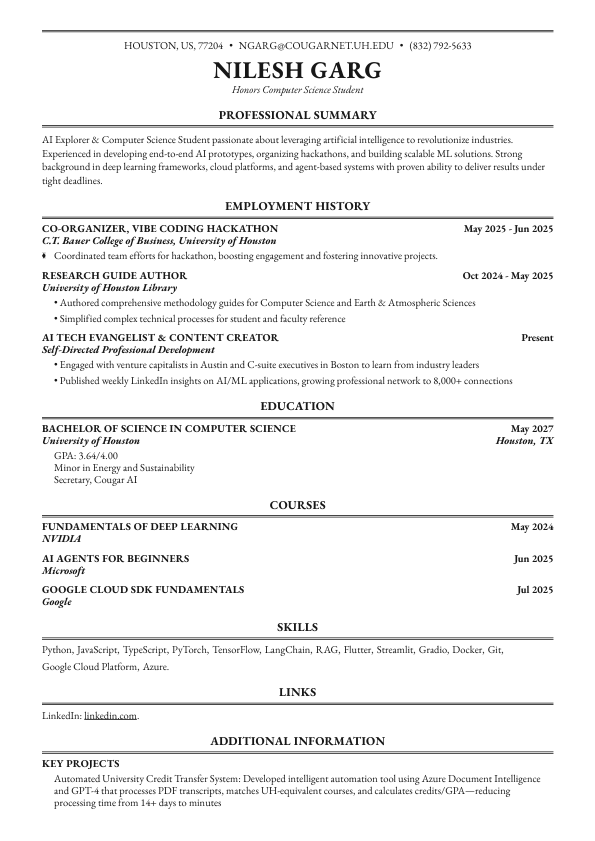

In [19]:
import cv2
import numpy as np
from PIL import Image

# Convert PDF page to an image
pix = doc[0].get_pixmap()
img = np.array(Image.frombytes("RGB", [pix.width, pix.height], pix.samples))

# Convert image to OpenCV BGR format
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

# Get the actual image height
img_height = img.shape[0]  # OpenCV uses (height, width, channels)

# Extract words and their bounding boxes
words = doc[0].get_text("words")

# Define the field we are looking for
target_word = "8327925633"  # Replace with actual phone number

# Flag to check if the word was found
word_found = False

# Search for the target word and retrieve its bounding box
for word in words:
    x0, y0, x1, y1, text, block, line, word_no = word  # Unpack correctly

    if target_word in text:  # Case-sensitive match (modify if needed)
        # Convert PyMuPDF's y-coordinates (bottom-left origin) to OpenCV's (top-left origin)
        y0_new = y1  # Convert bottom-left to top-left
        y1_new = y0  # Convert bottom-left to top-left

        # Convert coordinates to integers
        x0, y0_new, x1, y1_new = map(int, [x0, y0_new, x1, y1_new])

        # Draw a rectangle around the detected word
        cv2.rectangle(img, (x0, y0_new), (x1, y1_new), (0, 255, 0), 2)

        print(f"Found '{target_word}' at: ({x0}, {y0_new}, {x1}, {y1_new})")
        word_found = True

# Ensure an image is displayed even if no word is found
if not word_found:
    print(f"'{target_word}' not found in document.")

# Convert back to RGB for displaying in PIL
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image using PIL (works in Jupyter/Colab)
display(Image.fromarray(img_rgb))

In [20]:
Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).show()